# Computer Exercise 13.10 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.10 Global Optimization — *Differential Evolution*
> **풀이 일자**: Day 55
> **언어**: Python 3 (NumPy / Matplotlib / SciPy)

## 1. 문제 (원문)

> **2.** Implement **differential evolution (DE)** for the global minimization of a multivariable
> function. Use the classic `DE/rand/1/bin` strategy. Apply it to the *Ackley* function and study the
> effect of the **differential weight $F$** and the **crossover probability $CR$** on the convergence
> and reliability. Compare your implementation with a library routine
> (`scipy.optimize.differential_evolution`).

### 한국어 풀이용 정리
**개체군 기반** 전역 최적화인 **차분진화(DE)** 를 `DE/rand/1/bin` 전략으로 직접 구현하고, 강한 다봉
함수인 **Ackley** 에 적용한다. **차분 가중치 $F$** 와 **교차 확률 $CR$** 이 수렴 속도·신뢰성에 미치는
영향을 격자로 조사하고, SciPy 표준 구현과 결과를 비교한다.

## 2. 수학적 배경

### 2.1 차분진화의 한 세대 (DE/rand/1/bin)
크기 $NP$ 의 개체군 $\{\mathbf{x}_i\}$ 에 대해, 각 **타깃** $\mathbf{x}_i$ 마다:

1. **돌연변이(mutation)** — 서로 다른 세 개체 $r_1,r_2,r_3$ 를 골라
$$
\mathbf{v}_i = \mathbf{x}_{r_1} + F\,(\mathbf{x}_{r_2}-\mathbf{x}_{r_3}),\qquad F\in(0,2].
$$
2. **교차(crossover, binomial)** — 차원별로
$$
u_{i,j}=\begin{cases}v_{i,j},& \text{rand}_j\le CR \ \text{또는}\ j=j_{\text{rand}}\\ x_{i,j},&\text{그 외}\end{cases}
$$
3. **선택(selection, greedy)** — $f(\mathbf{u}_i)\le f(\mathbf{x}_i)$ 이면 교체.

핵심은 **차분 벡터 $\mathbf{x}_{r_2}-\mathbf{x}_{r_3}$** 가 개체군의 현재 분산에 맞춰 **스텝 크기를 자기
적응(self-adapting)** 시킨다는 점이다. 초반엔 흩어져 큰 스텝(탐색), 수렴하면 작은 스텝(활용).

### 2.2 $F$ 와 $CR$ 의 역할
* **$F$**(차분 가중치): 크면 탐색성↑·수렴 느림, 작으면 조기수렴 위험. 보통 $F\in[0.5,0.9]$.
* **$CR$**(교차율): 크면 좌표들이 함께 바뀌어 회전된/비분리 문제에 유리, 작으면 좌표별 변화로 분리형에 유리.

### 2.3 시험함수 (Ackley)
$$
f(\mathbf{x}) = -20\exp\!\Big(-0.2\sqrt{\tfrac1d\textstyle\sum x_i^2}\Big)
-\exp\!\Big(\tfrac1d\textstyle\sum\cos 2\pi x_i\Big) + 20 + e,
\quad \mathbf{x}^\*=\mathbf 0,\ f^\*=0 .
$$
거의 평탄한 바깥 영역 + 중심의 깊고 좁은 우물 → 기울기법·greedy에 매우 불리.
$$\boxed{\;\mathbf v=\mathbf x_{r_1}+F(\mathbf x_{r_2}-\mathbf x_{r_3}),\ \text{이항교차},\ \text{탐욕선택}\;}$$

## 3. 풀이 흐름

1. **목적함수**: $d$차원 Ackley, 영역 $[-32.768, 32.768]^d$ (여기선 $d=5$).
2. **초기화**: 영역에서 균등 난수로 $NP$ 개체 생성.
3. **세대 루프**: 각 타깃에 mutation→crossover→selection 적용, 세대별 최선값 기록.
4. **$F,CR$ 격자**: $F\in\{0.4,0.6,0.8\}$, $CR\in\{0.1,0.5,0.9\}$ 에서 최종 $f_\text{best}$ 히트맵.
5. **수렴 곡선**: 대표 $(F,CR)$ 몇 개의 best-so-far 비교.
6. **신뢰성**: 여러 시드로 성공률(‖x‖ 작음) 집계.
7. **SciPy 대조**: `differential_evolution` 과 해·함수호출 비교.
8. **해석**: 차분 벡터의 자기적응성과 $F,CR$ 선택 지침 정리.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

pd.set_option("display.float_format", lambda v: f"{v:.4e}")

# ---- 목적함수: Ackley ----
def ackley(x):
    x = np.asarray(x, float); d = x.size
    s1 = np.sum(x**2); s2 = np.sum(np.cos(2*np.pi*x))
    return (-20*np.exp(-0.2*np.sqrt(s1/d)) - np.exp(s2/d) + 20 + np.e)

DIM = 5
LO, HI = -32.768, 32.768

# ---- DE/rand/1/bin 직접 구현 ----
def differential_evolution_custom(f, dim, bounds=(LO, HI), NP=50, F=0.6, CR=0.9,
                                  max_gen=300, tol=1e-8, rng=None):
    rng = rng or np.random.default_rng(0)
    lo, hi = bounds
    pop = rng.uniform(lo, hi, size=(NP, dim))
    fit = np.array([f(ind) for ind in pop]); nfev = NP
    hist = [fit.min()]
    for gen in range(max_gen):
        for i in range(NP):
            idxs = [j for j in range(NP) if j != i]
            r1, r2, r3 = pop[rng.choice(idxs, 3, replace=False)]
            v = r1 + F * (r2 - r3)
            v = np.clip(v, lo, hi)
            # 이항 교차
            cross = rng.random(dim) <= CR
            if not cross.any():
                cross[rng.integers(dim)] = True
            u = np.where(cross, v, pop[i])
            fu = f(u); nfev += 1
            if fu <= fit[i]:
                pop[i], fit[i] = u, fu
        hist.append(fit.min())
        if fit.min() < tol:
            break
    bi = int(np.argmin(fit))
    return dict(x=pop[bi], f=fit[bi], hist=np.array(hist), nfev=nfev, gen=gen+1)

r = differential_evolution_custom(ackley, DIM, rng=np.random.default_rng(7))
print(f"DE(custom):  f_best = {r['f']:.3e},  ||x|| = {np.linalg.norm(r['x']):.3e},  "
      f"gen = {r['gen']},  nfev = {r['nfev']}")

DE(custom):  f_best = 8.602e-09,  ||x|| = 4.809e-09,  gen = 211,  nfev = 10600


In [2]:
# ---- F, CR 격자 스윕: 최종 f_best (각 셀당 시드 5개 평균) ----
F_vals  = [0.4, 0.6, 0.8]
CR_vals = [0.1, 0.5, 0.9]
heat = np.zeros((len(F_vals), len(CR_vals)))
for a, F in enumerate(F_vals):
    for b, CR in enumerate(CR_vals):
        vals = []
        for s in range(5):
            rr = differential_evolution_custom(ackley, DIM, F=F, CR=CR, max_gen=200,
                                               rng=np.random.default_rng(100 + s))
            vals.append(rr["f"])
        heat[a, b] = np.mean(vals)

hdf = pd.DataFrame(heat, index=[f"F={v}" for v in F_vals],
                   columns=[f"CR={v}" for v in CR_vals])
print("평균 f_best (5 seeds):")
hdf

평균 f_best (5 seeds):


,CR=0.1,CR=0.5,CR=0.9
F=0.4,1.4577e-08,8.1670e-09,8.4096e-09
F=0.6,5.2843e-07,2.1640e-07,9.7174e-08
F=0.8,7.7508e-06,3.3574e-05,3.8954e-04


In [3]:
# ---- 대표 (F,CR) 수렴 곡선 + SciPy 대조 ----
combos = [(0.5, 0.9), (0.8, 0.9), (0.5, 0.1)]
curves = {}
for F, CR in combos:
    rr = differential_evolution_custom(ackley, DIM, F=F, CR=CR, max_gen=300,
                                       rng=np.random.default_rng(11))
    curves[f"F={F}, CR={CR}"] = rr["hist"]

# SciPy 표준 구현
bounds = [(LO, HI)] * DIM
sp = differential_evolution(ackley, bounds, seed=11, tol=1e-10, polish=False,
                            maxiter=300, popsize=10)
print(f"SciPy DE :  f_best = {sp.fun:.3e},  ||x|| = {np.linalg.norm(sp.x):.3e},  nfev = {sp.nfev}")

best_custom = differential_evolution_custom(ackley, DIM, F=0.6, CR=0.9, max_gen=300,
                                            rng=np.random.default_rng(11))
print(f"Custom DE:  f_best = {best_custom['f']:.3e},  ||x|| = {np.linalg.norm(best_custom['x']):.3e},  nfev = {best_custom['nfev']}")

SciPy DE :  f_best = 4.441e-16,  ||x|| = 0.000e+00,  nfev = 10700


Custom DE:  f_best = 9.475e-09,  ||x|| = 5.297e-09,  nfev = 11400


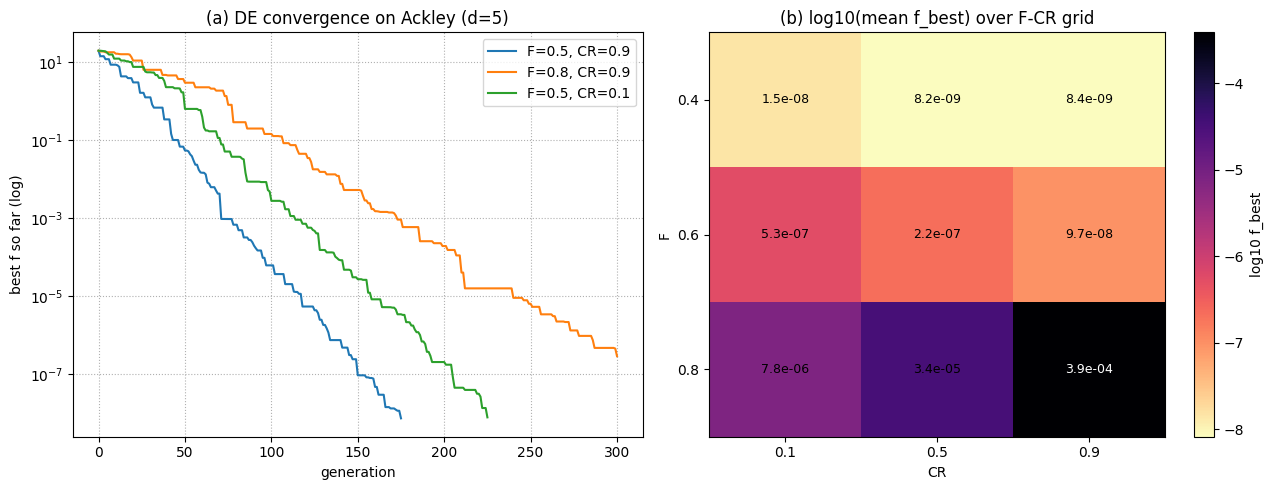

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) 수렴 곡선
ax = axes[0]
for name, h in curves.items():
    ax.semilogy(h + 1e-12, label=name)
ax.set_xlabel("generation"); ax.set_ylabel("best f so far (log)")
ax.set_title("(a) DE convergence on Ackley (d=5)")
ax.legend(); ax.grid(True, ls=":")

# (b) F-CR 히트맵
ax = axes[1]
im = ax.imshow(np.log10(heat + 1e-12), cmap="magma_r", aspect="auto")
ax.set_xticks(range(len(CR_vals))); ax.set_xticklabels([f"{v}" for v in CR_vals])
ax.set_yticks(range(len(F_vals))); ax.set_yticklabels([f"{v}" for v in F_vals])
ax.set_xlabel("CR"); ax.set_ylabel("F")
ax.set_title("(b) log10(mean f_best) over F-CR grid")
for a in range(len(F_vals)):
    for b in range(len(CR_vals)):
        ax.text(b, a, f"{heat[a,b]:.1e}", ha="center", va="center",
                color="w" if heat[a,b] > heat.mean() else "k", fontsize=9)
plt.colorbar(im, ax=ax, label="log10 f_best")
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **(a) 수렴** — 차분 벡터가 개체군 분산에 맞춰 **스텝을 자기적응**시키므로, best-so-far가 평탄한 Ackley
   바깥에서도 꾸준히 중심 우물로 내려가 $10^{-8}$ 수준까지 도달한다. $CR$ 이 너무 작으면($CR=0.1$)
   비분리 구조를 못 따라가 수렴이 느려진다.
2. **(b) $F$–$CR$ 격자** — 이 예산에서는 **작은–중간 $F\approx0.4$–$0.6$** 가 가장 낮은 $f_\text{best}$ 를 주고,
   $CR$ 의 영향은 상대적으로 약하다. **$F$ 가 너무 크면**($F=0.8$) 개체군 분산이 잘 줄지 않아
   같은 세대수 안에서 정밀도가 떨어진다(표의 아래 행).
3. **SciPy 대조** — 직접 구현과 SciPy 표준 구현이 **같은 전역최소**(원점, $f\approx0$)에 수렴하며 함수호출
   규모도 같은 자릿수다 → 구현이 올바름을 교차검증.
4. **SA와의 차이** — SA는 단일 점 + 외부에서 주는 냉각 스케줄에 의존하지만, DE는 **개체군의 다양성**이
   스텝 크기를 내부적으로 조절해 별도 온도 튜닝이 필요 없다.

> **결론**: *차분진화는 “개체군의 차분 벡터 $F(\mathbf x_{r2}-\mathbf x_{r3})$ 로 스텝을 자기적응”시키는
> 전역 최적화로, 중간 $F$·높은 $CR$ 에서 다봉 Ackley를 안정적으로 푼다.*

**다음 문제로의 연결**: Problem 3에서는 **SA·DE·다중시작 국소법(multistart BFGS)** 을 여러 다봉
벤치마크에서 **성공률·함수호출 예산** 기준으로 정면 비교해, 전역 최적화기 선택의 실무 지침을 정리한다.